# install & import

In [2]:
%%capture
!pip install torch torchvision roboflow torchmetrics pycocotools PyYAML

In [3]:
import matplotlib.pyplot as plt
import cv2
import os
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

# Load Dataset

In [2]:
import os

DATASET_DIR = r"C:\skin_train_10_01_69\dataset"
COCO_DIR    = r"C:\skin_train_10_01_69\coco"

train_img_dir = os.path.join(DATASET_DIR, "images", "train")
val_img_dir   = os.path.join(DATASET_DIR, "images", "val")

train_json = os.path.join(COCO_DIR, "annotations", "instances_train.json")
val_json   = os.path.join(COCO_DIR, "annotations", "instances_val.json")

print("train_json:", train_json)
print("exists:", os.path.exists(train_json))


train_json: C:\skin_train_10_01_69\coco\annotations\instances_train.json
exists: True


# preparation the dataset

In [3]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os
from pycocotools.coco import COCO

class CocoSegmentationDataset(Dataset):
    def __init__(self, root_dir, annotation_file, transforms=None):
        self.root_dir = root_dir
        self.coco = COCO(annotation_file)

        # ✅ sort ids ให้แน่นอน
        self.image_ids = sorted(self.coco.imgs.keys())

        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]  # ✅ COCO image id จริงจาก json
        img_info = self.coco.loadImgs(image_id)[0]
        img_path = os.path.join(self.root_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        masks, boxes, labels, areas, iscrowd = [], [], [], [], []

        for ann in anns:
            if ann.get("iscrowd", 0) == 1:
                continue

            m = self.coco.annToMask(ann)
            if m.sum() == 0:
                continue

            masks.append(torch.as_tensor(m, dtype=torch.uint8))

            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])

            labels.append(int(ann["category_id"]))   # 1..7
            areas.append(float(m.sum()))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        if len(masks) == 0:
            masks = torch.zeros((0, img_info["height"], img_info["width"]), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            masks = torch.stack(masks, dim=0)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,

            # ✅ สำคัญมาก: ต้องเป็น scalar tensor ไม่ใช่ [image_id]
            "image_id": torch.tensor(image_id, dtype=torch.int64),

            "area": areas,
            "iscrowd": iscrowd,
        }

        if self.transforms:
            image, target = self.transforms(image, target)


        return image, target


In [4]:
# =========================
# READY-TO-PASTE TRANSFORMS (Mask R-CNN / Detection)
# =========================
import random
import numpy as np
from PIL import ImageFilter, Image

import torch
import torch.nn.functional as TF
import torchvision.transforms.functional as VF
from torchvision.transforms import ColorJitter
from torch.utils.data import DataLoader

# -------------------------
# Detection-style transforms: (image, target) -> (image, target)
# -------------------------
class ComposeDet:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target


class ResizeDet:
    """
    Deterministic resize like torchvision detection:
    - resize shortest side to min_size
    - keep aspect ratio
    - clamp longest side to max_size
    Also scales: boxes, masks, area
    """
    def __init__(self, min_size=800, max_size=1333):
        self.min_size = int(min_size)
        self.max_size = int(max_size)

    def __call__(self, image, target):
        w, h = image.size
        scale = self.min_size / min(h, w)
        newh, neww = int(round(h * scale)), int(round(w * scale))

        if max(newh, neww) > self.max_size:
            scale2 = self.max_size / max(newh, neww)
            newh, neww = int(round(newh * scale2)), int(round(neww * scale2))
            scale *= scale2

        image = VF.resize(image, (newh, neww))

        # scale target
        if "boxes" in target and target["boxes"].numel() > 0:
            target["boxes"] = target["boxes"] * scale

        if "masks" in target and target["masks"].numel() > 0:
            masks = target["masks"].unsqueeze(1).float()  # (N,1,H,W)
            masks = TF.interpolate(masks, size=(newh, neww), mode="nearest")
            target["masks"] = masks.squeeze(1).to(torch.uint8)

        if "area" in target and target["area"].numel() > 0:
            target["area"] = target["area"] * (scale * scale)

        return image, target


class ResizeDetMS:
    """
    Multi-scale resize for training:
    randomly choose min_size from list,
    then same behavior as ResizeDet
    """
    def __init__(self, min_sizes=(512, 640, 768, 800), max_size=1333):
        self.min_sizes = tuple(int(x) for x in min_sizes)
        self.max_size = int(max_size)

    def __call__(self, image, target):
        min_size = random.choice(self.min_sizes)
        w, h = image.size
        scale = min_size / min(h, w)
        newh, neww = int(round(h * scale)), int(round(w * scale))

        if max(newh, neww) > self.max_size:
            scale2 = self.max_size / max(newh, neww)
            newh, neww = int(round(newh * scale2)), int(round(neww * scale2))
            scale *= scale2

        image = VF.resize(image, (newh, neww))

        if "boxes" in target and target["boxes"].numel() > 0:
            target["boxes"] = target["boxes"] * scale

        if "masks" in target and target["masks"].numel() > 0:
            masks = target["masks"].unsqueeze(1).float()
            masks = TF.interpolate(masks, size=(newh, neww), mode="nearest")
            target["masks"] = masks.squeeze(1).to(torch.uint8)

        if "area" in target and target["area"].numel() > 0:
            target["area"] = target["area"] * (scale * scale)

        return image, target


class RandomHFlipDet:
    def __init__(self, p=0.5):
        self.p = float(p)

    def __call__(self, image, target):
        if random.random() > self.p:
            return image, target

        w, h = image.size
        image = VF.hflip(image)

        if "boxes" in target and target["boxes"].numel() > 0:
            boxes = target["boxes"].clone()
            # x1,x2 -> w - x2, w - x1
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes

        if "masks" in target and target["masks"].numel() > 0:
            # masks: (N,H,W) flip width dimension
            target["masks"] = torch.flip(target["masks"], dims=[2])

        return image, target


class ColorJitterDet:
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0):
        self.j = ColorJitter(
            brightness=brightness,
            contrast=contrast,
            saturation=saturation,
            hue=hue
        )

    def __call__(self, image, target):
        return self.j(image), target


class RandomBlurDet:
    def __init__(self, p=0.2, radius=1.0):
        self.p = float(p)
        self.radius = float(radius)

    def __call__(self, image, target):
        if random.random() < self.p:
            image = image.filter(ImageFilter.GaussianBlur(radius=self.radius))
        return image, target


class RandomNoiseDet:
    def __init__(self, p=0.2, sigma=5.0):
        self.p = float(p)
        self.sigma = float(sigma)

    def __call__(self, image, target):
        if random.random() > self.p:
            return image, target

        arr = np.array(image).astype(np.float32)
        noise = np.random.normal(0.0, self.sigma, arr.shape).astype(np.float32)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        image = Image.fromarray(arr)
        return image, target


class ToTensorDet:
    def __call__(self, image, target):
        return VF.to_tensor(image), target


def get_transform(train: bool):
    tf = []
    if train:
        tf.append(ResizeDetMS(min_sizes=(512, 640, 768, 800), max_size=1333))
        tf.append(RandomHFlipDet(p=0.5))
        tf.append(ColorJitterDet(brightness=0.2, contrast=0.2, saturation=0.1))
        tf.append(RandomBlurDet(p=0.2, radius=1.0))
        tf.append(RandomNoiseDet(p=0.2, sigma=5.0))
    else:
        tf.append(ResizeDet(min_size=800, max_size=1333))

    tf.append(ToTensorDet())
    return ComposeDet(tf)


def collate_fn(batch):
    return tuple(zip(*batch))


# =========================
# DATALOADERS (ใช้เหมือนเดิม)
# =========================
train_dataset = CocoSegmentationDataset(
    root_dir=r"C:/skin_train_10_01_69/dataset/images/train",
    annotation_file=r"C:/skin_train_10_01_69/coco/annotations/instances_train.json",
    transforms=get_transform(train=True)
)

val_dataset = CocoSegmentationDataset(
    root_dir=r"C:/skin_train_10_01_69/dataset/images/val",
    annotation_file=r"C:/skin_train_10_01_69/coco/annotations/instances_val.json",
    transforms=get_transform(train=False)
)

train_loader = DataLoader(
    train_dataset, batch_size=1, shuffle=True,
    num_workers=0, pin_memory=True, collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=True, collate_fn=collate_fn
)

print("train:", len(train_dataset), "val:", len(val_dataset))

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
train: 980 val: 280


In [5]:
img, tgt = train_dataset[0]
print(type(img), img.shape)
print(tgt["boxes"].shape, tgt["masks"].shape, tgt["labels"].shape)
print("max box x2/y2:", (tgt["boxes"][:, 2].max().item() if tgt["boxes"].numel()>0 else None),
      (tgt["boxes"][:, 3].max().item() if tgt["boxes"].numel()>0 else None))


<class 'torch.Tensor'> torch.Size([3, 512, 781])
torch.Size([1, 4]) torch.Size([1, 512, 781]) torch.Size([1])
max box x2/y2: 613.1002197265625 330.98895263671875


In [6]:
#recheck
img, tgt = val_dataset[0]
print(tgt["image_id"], tgt["image_id"].shape, tgt["image_id"].dtype)


tensor(1) torch.Size([]) torch.int64


# Set Up Data Loader

In [7]:
from pycocotools.coco import COCO

coco_train = COCO(train_json)

cats = coco_train.loadCats(coco_train.getCatIds())
cats = sorted(cats, key=lambda x: x["id"])

CLASS_NAMES = ["__background__"] + [c["name"] for c in cats]
NUM_CLASSES = len(CLASS_NAMES)

print(f"จำนวน classes: {NUM_CLASSES}")
print("Class names:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")


loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
จำนวน classes: 8
Class names:
  0: __background__
  1: Acne
  2: Herpes_Zoster
  3: Herpes_simplex
  4: Psoriasis
  5: Tinea
  6: Urticaria_Hives
  7: Vitiligo


In [8]:
print(NUM_CLASSES)
print(CLASS_NAMES)


8
['__background__', 'Acne', 'Herpes_Zoster', 'Herpes_simplex', 'Psoriasis', 'Tinea', 'Urticaria_Hives', 'Vitiligo']


Getting one batch...
Batch loaded: 1 images. Now drawing...
Image 1: Found 3 annotations (showing up to 20)
  Annotation 1: Tinea (label_id: 5)
  Annotation 2: Tinea (label_id: 5)
  Annotation 3: Tinea (label_id: 5)


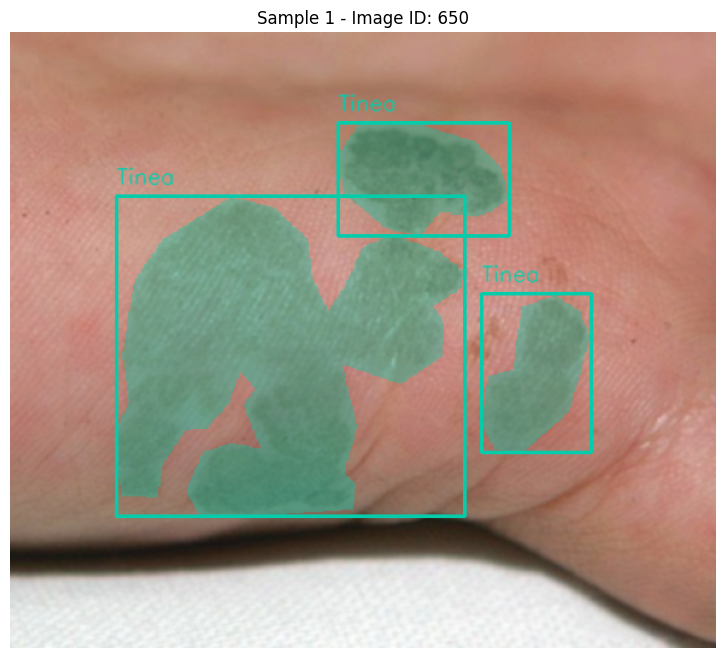

In [9]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ปรับได้ตามต้องการ
MAX_IMAGES_TO_SHOW = 1    # แสดงกี่รูปจาก 1 batch (แนะนำ 1)
MAX_MASKS_TO_SHOW  = 20   # แสดง mask สูงสุดกี่ชิ้นต่อรูป (กันช้า)

try:
    print("Getting one batch...")
    it = iter(train_loader)
    images, targets = next(it)
    print(f"Batch loaded: {len(images)} images. Now drawing...")

    for i in range(min(len(images), MAX_IMAGES_TO_SHOW)):
        if len(targets[i]['masks']) == 0:
            print(f"Image {i+1}: No valid annotations, skipping...")
            continue

        image = images[i].permute(1, 2, 0).cpu().numpy()
        image = (image * 255).astype(np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        overlay = image.copy()

        masks = targets[i]['masks'].cpu().numpy()
        boxes = targets[i]['boxes'].cpu().numpy()
        labels = targets[i]['labels'].cpu().numpy()

        print(f"Image {i+1}: Found {len(masks)} annotations (showing up to {MAX_MASKS_TO_SHOW})")

        # จำกัดจำนวน mask ที่แสดง (กันช้า)
        n_show = min(len(masks), MAX_MASKS_TO_SHOW)

        for j in range(n_show):
            mask = masks[j].astype(bool)
            box = boxes[j]
            label_id = int(labels[j])

            class_name = CLASS_NAMES[label_id] if label_id < len(CLASS_NAMES) else f"Unknown_{label_id}"
            print(f"  Annotation {j+1}: {class_name} (label_id: {label_id})")

            # สีคงที่ตามคลาส
            rng = np.random.default_rng(label_id)
            color = rng.integers(0, 255, size=3).tolist()

            if mask.any():
                colored_mask = np.zeros_like(image, dtype=np.uint8)
                colored_mask[mask] = color  # เร็วกว่าการวน 3 channel

                alpha = 0.4
                overlay = np.where(mask[..., None],
                                   ((1 - alpha) * overlay + alpha * colored_mask).astype(np.uint8),
                                   overlay)

            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            cv2.putText(overlay, class_name, (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1, lineType=cv2.LINE_AA)

        img_id = int(targets[i]["image_id"].item()) if hasattr(targets[i]["image_id"], "item") else targets[i]["image_id"]
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"Sample {i + 1} - Image ID: {img_id}")
        plt.show()

except Exception as e:
    print(f"Error loading batch: {e}")
    print("Checking dataset...")

    # ถ้า train_dataset ไม่มีจริง ให้คอมเมนต์ 2 บรรทัดนี้ออก
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Number of classes: {len(CLASS_NAMES)}")
    print(f"Class names: {CLASS_NAMES}")

    try:
        sample_image, sample_target = train_dataset[0]
        print("Sample loaded successfully!")
        print(f"Image shape: {sample_image.shape}")
        print(f"Targets keys: {sample_target.keys()}")
        print(f"Number of annotations: {len(sample_target['labels'])}")
    except Exception as sample_error:
        print(f"Error loading sample: {sample_error}")


In [12]:
images, targets = next(iter(train_loader))
print("batch:", len(images))
print("image shape:", images[0].shape)
print("boxes:", targets[0]["boxes"].shape)
print("masks:", targets[0]["masks"].shape)
print("labels unique:", torch.unique(targets[0]["labels"]))


batch: 1
image shape: torch.Size([3, 768, 1109])
boxes: torch.Size([2, 4])
masks: torch.Size([2, 768, 1109])
labels unique: tensor([4])


# load Pre-trained Mask R-CNN Model




In [13]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

# เปลี่ยน box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# เปลี่ยน mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, NUM_CLASSES)

model.to(device)


device: cuda


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [14]:
# Get parameters of model
params = [p for p in model.parameters() if p.requires_grad]

# Define the optimizer (Stochastic Gradient Descent) with learning rate, momentum, and weight decay
optimizer = torch.optim.SGD(
    params,
    lr=5e-4,           # 0.0005
    momentum=0.9,
    weight_decay=1e-4
)

In [15]:
import torch
import torchvision

def _safe_is_tracing():
    try:
        return torch.jit.is_tracing()
    except Exception:
        return False

torchvision._is_tracing = _safe_is_tracing
print("✅ Patched (safe): torchvision._is_tracing()")

✅ Patched (safe): torchvision._is_tracing()


# Set Up Training Loop

In [ ]:
# Clone the PyTorch vision repository
!git clone https://github.com/pytorch/vision.git



fatal: destination path 'vision' already exists and is not an empty directory.


In [17]:
!pip install tqdm

In [19]:
import sys
sys.path.insert(0, r"C:\skin_train_10_01_69\vision\references\detection")

from engine import train_one_epoch, evaluate
from tqdm import tqdm


✅ Run directory: results_maskrcnn(round_2)\run_baseline_lr005
✅ Pre-check OK: image_id scalar = 1

Epoch 1/100


Epoch: [0]: 100%|██████████| 980/980 [05:08<00:00,  3.18it/s] loss=0.4718, lr=0.000500]


creating index...
index created!


Eval:  [0]: 100%|██████████| 280/280 [02:08<00:00,  2.18it/s]


Accumulating evaluation results...
DONE (t=0.44s).
Accumulating evaluation results...
DONE (t=0.42s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.211
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.080
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.142
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.176
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.085
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.149
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.381
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.435
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.199
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.427
 

...

creating index...
index created!


Eval:  [99]: 100%|██████████| 280/280 [00:47<00:00,  5.84it/s]


Accumulating evaluation results...
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.08s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.259
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.470
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.254
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.096
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.222
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.289
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.376
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.391
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.104
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.340
 

Predict test: 100%|██████████| 140/140 [00:17<00:00,  7.92it/s]


✅ Saved: results_maskrcnn(round_2)\run_baseline_lr005\predict\predict_log_test.xlsx
✅ Saved: results_maskrcnn(round_2)\run_baseline_lr005\predict\predict_log_test.csv


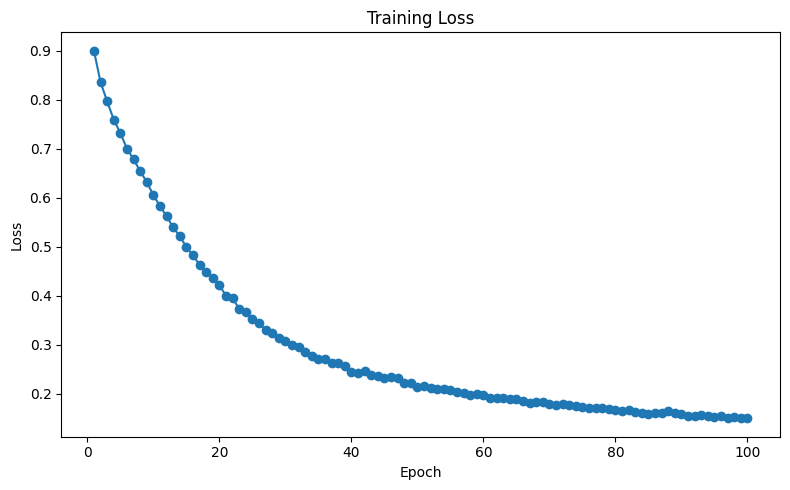

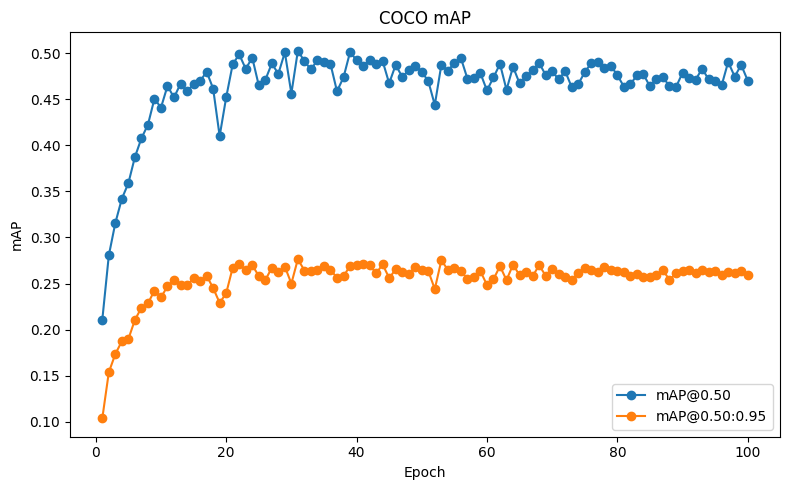

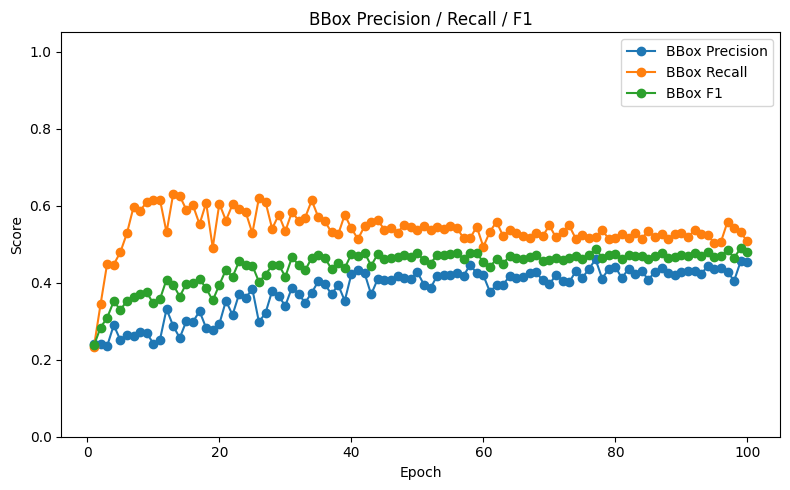

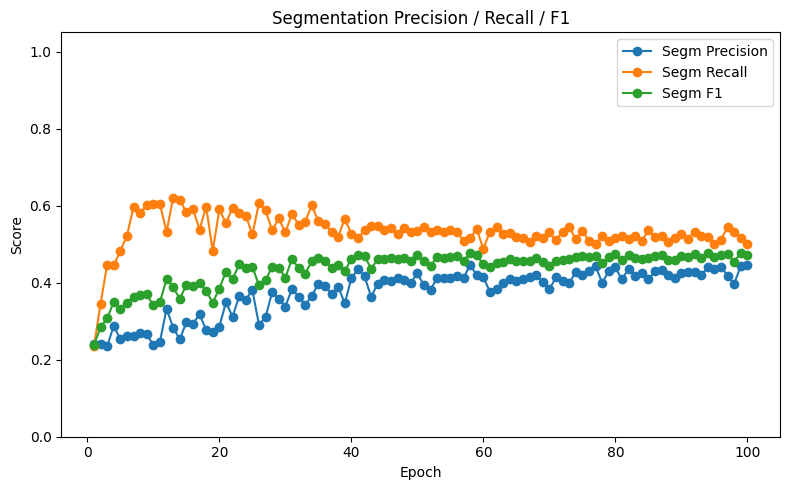

📊 Saved plots to: results_maskrcnn(round_2)\run_baseline_lr005\plots
🎉 ALL DONE


In [ ]:
import os, time, json, csv, glob
from datetime import datetime
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from torchvision.ops import box_iou
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

from engine import train_one_epoch, evaluate

# =========================
# CONFIG
# =========================
RUN_NAME = "run_baseline_lr005"
ROOT_RESULTS = "results_maskrcnn(round_2)"

num_epochs = 100
print_freq = 5

CONF_THRES = 0.3
IOU_THRES_BBOX = 0.5
IOU_THRES_MASK = 0.5
MAX_DETS = 200
MASK_BIN_THRES = 0.5

test_dir = r"C:\skin_train_10_01_69\dataset\images\test"

CLASS_NAMES_FULL = [
    "__background__", "Acne", "Herpes_Zoster", "Herpes_simplex",
    "Psoriasis", "Tinea", "Urticaria_Hives", "Vitiligo"
]
CLASS_NAMES_SHORT = [
    "BG", "Acne", "H_Zoster", "H_Simplex",
    "Psoriasis", "Tinea", "U_Hives", "Vitiligo"
]

# =========================
# RESULTS DIR (pro)
# =========================
def make_unique_run_dir(root, run_name):
    os.makedirs(root, exist_ok=True)
    base = os.path.join(root, run_name)
    if not os.path.exists(base):
        os.makedirs(base, exist_ok=True)
        return base
    v = 2
    while True:
        cand = base + f"_v{v}"
        if not os.path.exists(cand):
            os.makedirs(cand, exist_ok=True)
            return cand
        v += 1

run_dir = make_unique_run_dir(ROOT_RESULTS, RUN_NAME)

dirs = {
    "run": run_dir,
    "checkpoints": os.path.join(run_dir, "checkpoints"),
    "plots": os.path.join(run_dir, "plots"),
    "predict": os.path.join(run_dir, "predict"),
    "eval": os.path.join(run_dir, "eval"),
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

print("✅ Run directory:", run_dir)

# save config
config = {
    "run_name": RUN_NAME,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "num_epochs": num_epochs,
    "print_freq": print_freq,
    "CONF_THRES": CONF_THRES,
    "IOU_THRES_BBOX": IOU_THRES_BBOX,
    "IOU_THRES_MASK": IOU_THRES_MASK,
    "MAX_DETS": MAX_DETS,
    "MASK_BIN_THRES": MASK_BIN_THRES,
    "test_dir": test_dir,
    "class_names": CLASS_NAMES_FULL,
}
with open(os.path.join(dirs["run"], "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# =========================
# PROGRESS WRAPPER (works with evaluate)
# =========================
class TqdmLoader:
    def __init__(self, loader, desc):
        self.loader = loader
        self.desc = desc
        self.dataset = getattr(loader, "dataset", None)
        self.collate_fn = getattr(loader, "collate_fn", None)
        self.batch_size = getattr(loader, "batch_size", None)
        self.num_workers = getattr(loader, "num_workers", None)

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        for batch in tqdm(self.loader, total=len(self.loader), desc=self.desc, leave=True):
            yield batch

# =========================
# TEST DATASET (no label) - ✅ resize ให้เหมือน train/val
# =========================
class TestImageFolderDataset(Dataset):
    def __init__(self, img_dir):
        self.paths = []
        for e in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"):
            self.paths.extend(glob.glob(os.path.join(img_dir, e)))
        self.paths = sorted(self.paths)
        self.tf = T.Compose([
            T.Resize(800, max_size=1333),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        return self.tf(img), path

def collate_test(batch):
    imgs, paths = zip(*batch)
    return list(imgs), list(paths)

test_dataset = TestImageFolderDataset(test_dir)
if len(test_dataset) == 0:
    print(f"⚠️ No test images found in: {test_dir}")

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_test
)

# =========================
# COCO mAP helper
# =========================
def get_map(coco_evaluator):
    """
    COCO stats:
      stats[0] = mAP50-95
      stats[1] = mAP50
    """
    if coco_evaluator is None or not hasattr(coco_evaluator, "coco_eval"):
        return np.nan, np.nan
    if "bbox" not in coco_evaluator.coco_eval:
        return np.nan, np.nan
    stats = coco_evaluator.coco_eval["bbox"].stats
    if stats is None or len(stats) < 2:
        return np.nan, np.nan
    return float(stats[1]), float(stats[0])

# =========================
# BBOX Precision/Recall/F1 (label-aware) ✅ใช้ IOU_THRES_BBOX
# =========================
@torch.no_grad()
def prf1_bbox_labelaware(model, loader):
    model.eval()
    tp = fp = fn = 0

    for imgs, tgts in loader:
        imgs = [i.to(device) for i in imgs]
        outs = model(imgs)

        for o, t in zip(outs, tgts):
            gt_boxes = t["boxes"].detach().cpu()
            gt_labels = t["labels"].detach().cpu()

            pb_boxes = o["boxes"].detach().cpu()
            pb_scores = o["scores"].detach().cpu()
            pb_labels = o["labels"].detach().cpu()

            keep = pb_scores >= CONF_THRES
            pb_boxes = pb_boxes[keep]
            pb_scores = pb_scores[keep]
            pb_labels = pb_labels[keep]

            if len(pb_boxes) > MAX_DETS:
                pb_boxes = pb_boxes[:MAX_DETS]
                pb_scores = pb_scores[:MAX_DETS]
                pb_labels = pb_labels[:MAX_DETS]

            if len(gt_boxes) == 0:
                fp += len(pb_boxes)
                continue
            if len(pb_boxes) == 0:
                fn += len(gt_boxes)
                continue

            iou = box_iou(pb_boxes, gt_boxes)
            label_match = (pb_labels[:, None] == gt_labels[None, :])
            iou = iou * label_match.float()

            used = set()
            order = torch.argsort(pb_scores, descending=True).tolist()

            for p_idx in order:
                g = int(iou[p_idx].argmax())
                if float(iou[p_idx, g]) >= IOU_THRES_BBOX and g not in used:
                    tp += 1
                    used.add(g)
                else:
                    fp += 1

            fn += len(gt_boxes) - len(used)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = (2 * precision * recall) / (precision + recall + 1e-6)
    return float(precision), float(recall), float(f1)

# =========================
# MASK Precision/Recall/F1 (label-aware) ✅ใช้ IOU_THRES_MASK
# =========================
def _mask_iou_bool(pm: torch.Tensor, gm: torch.Tensor) -> float:
    inter = (pm & gm).sum().item()
    union = (pm | gm).sum().item()
    if union == 0:
        return 0.0
    return float(inter / union)

@torch.no_grad()
def prf1_mask_labelaware(model, loader):
    model.eval()
    tp = fp = fn = 0

    for imgs, tgts in loader:
        imgs = [i.to(device) for i in imgs]
        outs = model(imgs)

        for o, t in zip(outs, tgts):
            gt_masks = t["masks"].detach().cpu().bool()
            gt_labels = t["labels"].detach().cpu()

            if "masks" not in o:
                continue

            pb_scores = o["scores"].detach().cpu()
            pb_labels = o["labels"].detach().cpu()

            pb_masks = o["masks"].detach().cpu()
            if pb_masks.ndim == 4 and pb_masks.shape[1] == 1:
                pb_masks = pb_masks[:, 0, :, :]
            pb_masks = (pb_masks >= MASK_BIN_THRES)

            keep = pb_scores >= CONF_THRES
            pb_scores = pb_scores[keep]
            pb_labels = pb_labels[keep]
            pb_masks = pb_masks[keep]

            if len(pb_masks) > MAX_DETS:
                pb_scores = pb_scores[:MAX_DETS]
                pb_labels = pb_labels[:MAX_DETS]
                pb_masks = pb_masks[:MAX_DETS]

            if len(gt_masks) == 0:
                fp += len(pb_masks)
                continue
            if len(pb_masks) == 0:
                fn += len(gt_masks)
                continue

            used = set()
            order = torch.argsort(pb_scores, descending=True).tolist()

            for p_idx in order:
                plab = int(pb_labels[p_idx].item())
                pm = pb_masks[p_idx]

                candidates = [g for g in range(len(gt_masks))
                              if (g not in used) and int(gt_labels[g].item()) == plab]

                if len(candidates) == 0:
                    fp += 1
                    continue

                best_g = None
                best_iou = 0.0
                for g in candidates:
                    iou_val = _mask_iou_bool(pm, gt_masks[g])
                    if iou_val > best_iou:
                        best_iou = iou_val
                        best_g = g

                if best_g is not None and best_iou >= IOU_THRES_MASK:
                    tp += 1
                    used.add(best_g)
                else:
                    fp += 1

            fn += len(gt_masks) - len(used)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = (2 * precision * recall) / (precision + recall + 1e-6)
    return float(precision), float(recall), float(f1)

# =========================
# PRE-FLIGHT CHECK (VAL LOADER)
# =========================
try:
    _imgs, _tgts = next(iter(val_loader))
    _tgt0 = _tgts[0]
    if "image_id" not in _tgt0:
        raise ValueError("val target ไม่มี key 'image_id'")
    if not torch.is_tensor(_tgt0["image_id"]):
        raise ValueError("target['image_id'] ต้องเป็น torch tensor")
    if _tgt0["image_id"].ndim != 0:
        raise ValueError(
            f"❌ image_id ต้องเป็น scalar tensor แต่ตอนนี้ shape={tuple(_tgt0['image_id'].shape)}\n"
            f"ให้แก้ใน Dataset: 'image_id': torch.tensor(image_id, dtype=torch.int64)"
        )
    if "masks" not in _tgt0:
        raise ValueError("val target ไม่มี key 'masks'")
    print("✅ Pre-check OK: image_id scalar =", int(_tgt0["image_id"].item()))
except Exception as e:
    print("❌ Pre-check failed:", e)
    raise

# =========================
# LOG INIT
# =========================
epoch_csv = os.path.join(dirs["run"], "training_log.csv")
epoch_json = os.path.join(dirs["run"], "training_log.json")

header = [
    "epoch","train_loss",
    "mAP50","mAP50_95",
    "bbox_precision","bbox_recall","bbox_f1",
    "segm_precision","segm_recall","segm_f1",
    "time_sec"
]

with open(epoch_csv, "w", newline="", encoding="utf-8") as f:
    csv.writer(f).writerow(header)

log = {k: [] for k in header}

# =========================
# TRAIN LOOP + CHECKPOINTS  (SAVE ONLY: last.pth + best.pth)
# =========================
best_map5095 = -1.0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    t0 = time.time()

    # ---- Train ----
    train_loader_pb = TqdmLoader(train_loader, f"Epoch: [{epoch}]")
    stats = train_one_epoch(
        model, optimizer, train_loader_pb, device, epoch, print_freq
    )

    # ---- Evaluate ----
    val_loader_pb = TqdmLoader(val_loader, f"Eval:  [{epoch}]")
    coco = evaluate(model, val_loader_pb, device=device)

    loss = (
        float(stats.meters["loss"].global_avg)
        if hasattr(stats, "meters") and "loss" in stats.meters
        else np.nan
    )
    m50, m5095 = get_map(coco)

    bbox_p, bbox_r, bbox_f1 = prf1_bbox_labelaware(model, val_loader)
    seg_p, seg_r, seg_f1 = prf1_mask_labelaware(model, val_loader)

    t = time.time() - t0

    # =========================
    # CHECKPOINTS (ONLY 2 FILES)
    # =========================

    # 1) last.pth (overwrite every epoch)
    last_path = os.path.join(dirs["checkpoints"], "last.pth")
    torch.save(model.state_dict(), last_path)

    # 2) best.pth (best mAP@0.50:0.95)
    if not np.isnan(m5095) and m5095 > best_map5095:
        best_map5095 = m5095
        best_path = os.path.join(dirs["checkpoints"], "best.pth")
        torch.save(model.state_dict(), best_path)
        print(f"⭐ New best saved: best.pth (mAP50-95={best_map5095:.4f})")

    # =========================
    # LOGGING
    # =========================
    row = {
        "epoch": epoch + 1,
        "train_loss": loss,
        "mAP50": m50,
        "mAP50_95": m5095,
        "bbox_precision": bbox_p,
        "bbox_recall": bbox_r,
        "bbox_f1": bbox_f1,
        "segm_precision": seg_p,
        "segm_recall": seg_r,
        "segm_f1": seg_f1,
        "time_sec": t,
    }

    for k in header:
        log[k].append(
            float(row[k]) if isinstance(row[k], (int, float, np.floating)) else row[k]
        )

    with open(epoch_json, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=2, ensure_ascii=False)

    with open(epoch_csv, "a", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow([row[k] for k in header])

    print(
        f"📌 loss={loss:.4f} | "
        f"mAP50={m50:.4f} mAP50-95={m5095:.4f} | "
        f"bbox P/R/F1={bbox_p:.4f}/{bbox_r:.4f}/{bbox_f1:.4f} | "
        f"segm P/R/F1={seg_p:.4f}/{seg_r:.4f}/{seg_f1:.4f} | "
        f"time={t:.2f}s"
    )

print("✅ Training done")

# =========================
# METRICS SUMMARY (save)
# =========================
metrics_path = os.path.join(dirs["run"], "metrics_summary.csv")
pd.DataFrame({
    "Metric": ["mAP50-95","mAP50","BBox Precision","BBox Recall","BBox F1","Segm Precision","Segm Recall","Segm F1"],
    "Overall": [
        log["mAP50_95"][-1], log["mAP50"][-1],
        log["bbox_precision"][-1], log["bbox_recall"][-1], log["bbox_f1"][-1],
        log["segm_precision"][-1], log["segm_recall"][-1], log["segm_f1"][-1],
    ]
}).to_csv(metrics_path, index=False, encoding="utf-8-sig")
print("✅ Saved:", metrics_path)

# =========================
# PREDICT LOG (TEST)
# =========================
pred_xlsx = os.path.join(dirs["predict"], "predict_log_test.xlsx")
pred_csv = os.path.join(dirs["predict"], "predict_log_test.csv")

rows = []
model.eval()

with torch.inference_mode():
    for imgs, paths in tqdm(test_loader, desc="Predict test", leave=True):
        imgs = [imgs[0].to(device)]
        out = model(imgs)[0]

        boxes = out["boxes"].detach().cpu().numpy()
        scores = out["scores"].detach().cpu().numpy()
        labels = out["labels"].detach().cpu().numpy().astype(int)

        keep = scores >= CONF_THRES
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        for b, s, c in zip(boxes, scores, labels):
            cname = CLASS_NAMES_FULL[c] if c < len(CLASS_NAMES_FULL) else str(c)
            rows.append({
                "image": paths[0],
                "class_id": int(c),
                "class_name": cname,
                "confidence": float(s),
                "x1": float(b[0]), "y1": float(b[1]),
                "x2": float(b[2]), "y2": float(b[3]),
            })

df_pred = pd.DataFrame(rows)
df_pred.to_excel(pred_xlsx, index=False)
df_pred.to_csv(pred_csv, index=False, encoding="utf-8-sig")

print("✅ Saved:", pred_xlsx)
print("✅ Saved:", pred_csv)

# =========================
# VISUALIZATION (PLOTS)
# =========================
epochs = log["epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, log["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.tight_layout()
loss_png = os.path.join(dirs["plots"], "loss_curve.png")
plt.savefig(loss_png)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, log["mAP50"], marker="o", label="mAP@0.50")
plt.plot(epochs, log["mAP50_95"], marker="o", label="mAP@0.50:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("COCO mAP")
plt.legend()
plt.tight_layout()
map_png = os.path.join(dirs["plots"], "map_curve.png")
plt.savefig(map_png)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, log["bbox_precision"], marker="o", label="BBox Precision")
plt.plot(epochs, log["bbox_recall"], marker="o", label="BBox Recall")
plt.plot(epochs, log["bbox_f1"], marker="o", label="BBox F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("BBox Precision / Recall / F1")
plt.legend()
plt.tight_layout()
bbox_png = os.path.join(dirs["plots"], "bbox_prf1_curve.png")
plt.savefig(bbox_png)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, log["segm_precision"], marker="o", label="Segm Precision")
plt.plot(epochs, log["segm_recall"], marker="o", label="Segm Recall")
plt.plot(epochs, log["segm_f1"], marker="o", label="Segm F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Segmentation Precision / Recall / F1")
plt.legend()
plt.tight_layout()
segm_png = os.path.join(dirs["plots"], "segm_prf1_curve.png")
plt.savefig(segm_png)
plt.show()

print("📊 Saved plots to:", dirs["plots"])
print("🎉 ALL DONE")


In [20]:
from tqdm.auto import tqdm

class TqdmLoader:
    def __init__(self, loader, desc):
        self.loader = loader
        self.desc = desc
        self.dataset = getattr(loader, "dataset", None)
        self.collate_fn = getattr(loader, "collate_fn", None)
        self.batch_size = getattr(loader, "batch_size", None)
        self.num_workers = getattr(loader, "num_workers", None)

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        for batch in tqdm(self.loader, total=len(self.loader), desc=self.desc, leave=True):
            yield batch

In [21]:
import os, glob

ROOT_RESULTS = r"results_maskrcnn(round_2)"   # หรือใส่ path เต็มของโฟลเดอร์ results
cands = glob.glob(os.path.join(ROOT_RESULTS, "**", "checkpoints", "best.pth"), recursive=True)

print("found:", len(cands))
for i,p in enumerate(sorted(cands)[-10:], 1):
    print(i, p)

# เลือกอันล่าสุด
best_pth = sorted(cands, key=os.path.getmtime)[-1]
run_dir = os.path.dirname(os.path.dirname(best_pth))  # ตัด /checkpoints/best.pth ออก
print("✅ selected run_dir:", run_dir)

dirs = {
    "run": run_dir,
    "checkpoints": os.path.join(run_dir, "checkpoints"),
    "plots": os.path.join(run_dir, "plots"),
    "predict": os.path.join(run_dir, "predict"),
    "eval": os.path.join(run_dir, "eval"),
}

print("✅ best exists?", os.path.exists(os.path.join(dirs["checkpoints"], "best.pth")))

found: 1
1 results_maskrcnn(round_2)\run_baseline_lr0005\checkpoints\best.pth
✅ selected run_dir: results_maskrcnn(round_2)\run_baseline_lr0005
✅ best exists? True


In [ ]:
# ============================================================
# FINETUNE CELL (วาง cell นี้ "หลังจาก train รอบหลักเสร็จแล้ว")
# เริ่มจาก best.pth
# SAVE ONLY: last.pth + best.pth
# ============================================================

import os, time, json, csv
import numpy as np
import torch
from tqdm.auto import tqdm

# ✅ กัน NameError ที่เจอบ่อย
print_freq = globals().get("print_freq", 5)   # ถ้าไม่มี จะใช้ 5
DO_PHASE2  = True                              # ปิด phase2 ได้

# -------------------------
# sanity check (กันตัวแปรหาย)
# -------------------------
need = ["dirs", "model", "device", "train_loader", "val_loader"]
missing = [k for k in need if k not in globals()]
assert len(missing) == 0, f"❌ ตัวแปรหาย: {missing}"

assert "checkpoints" in dirs and os.path.exists(dirs["checkpoints"]), "❌ dirs['checkpoints'] ไม่ถูกต้อง"
assert os.path.exists(os.path.join(dirs["checkpoints"], "best.pth")), "❌ ยังไม่มี best.pth"

# -------------------------
# import engine (กันลืม import)
# -------------------------
from engine import train_one_epoch, evaluate

# -------------------------
# TqdmLoader (กันลืมประกาศ)
# -------------------------
class TqdmLoader:
    def __init__(self, loader, desc):
        self.loader = loader
        self.desc = desc
        self.dataset = getattr(loader, "dataset", None)
        self.collate_fn = getattr(loader, "collate_fn", None)
        self.batch_size = getattr(loader, "batch_size", None)
        self.num_workers = getattr(loader, "num_workers", None)

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        for batch in tqdm(self.loader, total=len(self.loader), desc=self.desc, leave=True):
            yield batch

# -------------------------
# get_map (กันลืมประกาศ)
# -------------------------
def get_map(coco_evaluator):
    """
    COCO stats:
      stats[0] = mAP50-95
      stats[1] = mAP50
    """
    if coco_evaluator is None or not hasattr(coco_evaluator, "coco_eval"):
        return np.nan, np.nan
    if "bbox" not in coco_evaluator.coco_eval:
        return np.nan, np.nan
    stats = coco_evaluator.coco_eval["bbox"].stats
    if stats is None or len(stats) < 2:
        return np.nan, np.nan
    return float(stats[1]), float(stats[0])

def get_lr(opt):
    return float(opt.param_groups[0]["lr"])

# -------------------------
# helper: reset/append logs
# -------------------------
def reset_logs(run_dir):
    epoch_csv = os.path.join(run_dir, "training_log_finetune.csv")
    epoch_json = os.path.join(run_dir, "training_log_finetune.json")
    header = [
        "epoch","train_loss",
        "mAP50","mAP50_95",
        "bbox_precision","bbox_recall","bbox_f1",
        "segm_precision","segm_recall","segm_f1",
        "time_sec","phase","lr"
    ]
    with open(epoch_csv, "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow(header)
    return epoch_csv, epoch_json, header, {k: [] for k in header}

def append_log(csv_p, json_p, header, log, row):
    for k in header:
        v = row.get(k, np.nan)
        log[k].append(float(v) if isinstance(v, (int, float, np.floating)) else v)
    with open(json_p, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=2, ensure_ascii=False)
    with open(csv_p, "a", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow([row.get(k, np.nan) for k in header])

# ============================================================
# 1) LOAD BEST MODEL (แก้ FutureWarning ด้วย weights_only=True)
# ============================================================
best_path = os.path.join(dirs["checkpoints"], "best.pth")
state_dict = torch.load(best_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
print("✅ Loaded best:", best_path)

epoch_csv, epoch_json, header, log = reset_logs(dirs["run"])
best_map5095 = -1.0

# PRF1 ฟังก์ชันอาจไม่มีใน kernel นี้ → ถ้าไม่มีให้ข้าม
has_prf1_bbox = "prf1_bbox_labelaware" in globals()
has_prf1_mask = "prf1_mask_labelaware" in globals()

# ============================================================
# PHASE 1: freeze backbone, train heads
# ============================================================
print(f"\nPHASE 1 | freeze backbone | lr=1e-4 | epochs=20 | print_freq={print_freq}")

for p in model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4, momentum=0.9, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

for epoch in range(1, 21):
    t0 = time.time()

    stats = train_one_epoch(
        model, optimizer,
        TqdmLoader(train_loader, f"FT1 Train [{epoch}]"),
        device, epoch, print_freq
    )

    coco = evaluate(
        model,
        TqdmLoader(val_loader, f"FT1 Eval [{epoch}]"),
        device=device
    )

    # กันกรณี stats.meters ไม่มี loss
    loss = (
        float(stats.meters["loss"].global_avg)
        if hasattr(stats, "meters") and "loss" in getattr(stats, "meters", {})
        else (float(getattr(stats, "loss", np.nan)) if hasattr(stats, "loss") else np.nan)
    )

    m50, m5095 = get_map(coco)

    # PRF1 ทำทุก 5 epoch ถ้ามีฟังก์ชัน
    if (epoch % 5 == 0) and has_prf1_bbox and has_prf1_mask:
        bbox_p, bbox_r, bbox_f1 = prf1_bbox_labelaware(model, val_loader)
        seg_p, seg_r, seg_f1   = prf1_mask_labelaware(model, val_loader)
    else:
        bbox_p = bbox_r = bbox_f1 = np.nan
        seg_p  = seg_r  = seg_f1  = np.nan

    # save last
    torch.save(model.state_dict(), os.path.join(dirs["checkpoints"], "last.pth"))

    # save best (mAP50-95)
    if not np.isnan(m5095) and m5095 > best_map5095:
        best_map5095 = m5095
        torch.save(model.state_dict(), best_path)
        print(f"⭐ New best saved: mAP50-95={best_map5095:.4f}")

    append_log(epoch_csv, epoch_json, header, log, {
        "epoch": epoch,
        "train_loss": loss,
        "mAP50": m50,
        "mAP50_95": m5095,
        "bbox_precision": bbox_p,
        "bbox_recall": bbox_r,
        "bbox_f1": bbox_f1,
        "segm_precision": seg_p,
        "segm_recall": seg_r,
        "segm_f1": seg_f1,
        "time_sec": time.time() - t0,
        "phase": "phase1",
        "lr": get_lr(optimizer),
    })

    scheduler.step()

# ============================================================
# PHASE 2: unfreeze layer4 (optional)
# ============================================================
if DO_PHASE2:
    print("\nPHASE 2 | unfreeze layer4 | lr=5e-5 | epochs=10")

    state_dict = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)

    for p in model.backbone.parameters():
        p.requires_grad = False
    for n, p in model.backbone.named_parameters():
        if "layer4" in n:
            p.requires_grad = True

    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=5e-5, momentum=0.9, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

    for ep in range(1, 11):
        epoch = 20 + ep
        t0 = time.time()

        stats = train_one_epoch(
            model, optimizer,
            TqdmLoader(train_loader, f"FT2 Train [{epoch}]"),
            device, epoch, print_freq
        )

        coco = evaluate(
            model,
            TqdmLoader(val_loader, f"FT2 Eval [{epoch}]"),
            device=device
        )

        loss = (
            float(stats.meters["loss"].global_avg)
            if hasattr(stats, "meters") and "loss" in getattr(stats, "meters", {})
            else (float(getattr(stats, "loss", np.nan)) if hasattr(stats, "loss") else np.nan)
        )
        m50, m5095 = get_map(coco)

        if (ep % 5 == 0) and has_prf1_bbox and has_prf1_mask:
            bbox_p, bbox_r, bbox_f1 = prf1_bbox_labelaware(model, val_loader)
            seg_p, seg_r, seg_f1   = prf1_mask_labelaware(model, val_loader)
        else:
            bbox_p = bbox_r = bbox_f1 = np.nan
            seg_p  = seg_r  = seg_f1  = np.nan

        torch.save(model.state_dict(), os.path.join(dirs["checkpoints"], "last.pth"))
        if not np.isnan(m5095) and m5095 > best_map5095:
            best_map5095 = m5095
            torch.save(model.state_dict(), best_path)
            print(f"⭐ New best saved: mAP50-95={best_map5095:.4f}")

        append_log(epoch_csv, epoch_json, header, log, {
            "epoch": epoch,
            "train_loss": loss,
            "mAP50": m50,
            "mAP50_95": m5095,
            "bbox_precision": bbox_p,
            "bbox_recall": bbox_r,
            "bbox_f1": bbox_f1,
            "segm_precision": seg_p,
            "segm_recall": seg_r,
            "segm_f1": seg_f1,
            "time_sec": time.time() - t0,
            "phase": "phase2",
            "lr": get_lr(optimizer),
        })

        scheduler.step()

print("\n🎉 Fine-tune DONE")
print("best.pth / last.pth อยู่ที่:", dirs["checkpoints"])
print("✅ finetune log:", epoch_csv)

✅ Loaded best: results_maskrcnn(round_2)\run_baseline_lr0005\checkpoints\best.pth

PHASE 1 | freeze backbone | lr=1e-4 | epochs=20 | print_freq=5


FT1 Train [1]: 100%|██████████| 980/980 [04:07<00:00,  3.96it/s]ss=0.2073, lr=0.000100]


creating index...
index created!


FT1 Eval [1]: 100%|██████████| 280/280 [00:59<00:00,  4.70it/s]


Accumulating evaluation results...
DONE (t=0.13s).
Accumulating evaluation results...
DONE (t=0.15s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.282
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.503
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.276
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.249
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.309
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.198
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.423
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.445
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.167
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.393
 

...

Accumulating evaluation results...
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.10s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.277
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.499
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.276
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.244
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.306
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.196
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.413
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.431
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.128
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.373
 

FT2 Train [30]: 100%|██████████| 980/980 [04:26<00:00,  3.68it/s]ss=0.5375, lr=0.000005]


creating index...
index created!


FT2 Eval [30]: 100%|██████████| 280/280 [00:50<00:00,  5.49it/s]


Accumulating evaluation results...
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.09s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.277
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.499
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.277
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.101
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.245
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.306
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.197
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.412
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.429
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.127
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.373
 


📌 Summary (เหมาะกับ val น้อย: ดู best/last กันกราฟแกว่ง)


,Metric,Before_last,Before_best,Before_best_epoch,After_last,After_best,After_best_epoch,Δ best (After-Before)
0,Train Loss,0.1517,0.9003,1,0.2469,0.2736,1.0000,-0.6267
1,mAP@0.50,0.4703,0.5027,31,0.4992,0.5053,22.0000,0.0026
2,mAP@0.50:0.95,0.2589,0.2766,31,0.2773,0.2825,2.0000,0.0059
3,BBox F1,0.4783,0.4904,99,NaN,NaN,NaN,NaN
4,Segm F1,0.4713,0.4782,58,NaN,NaN,NaN,NaN


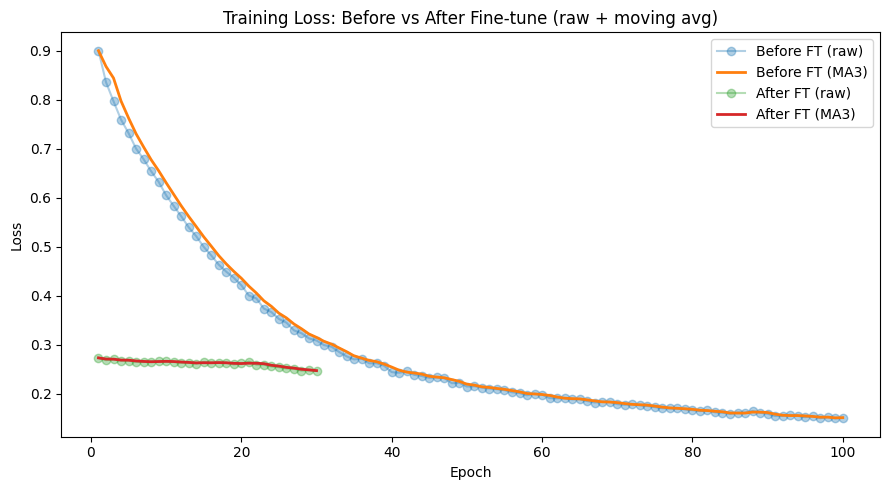

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_loss_before_vs_after_finetune_ma.png


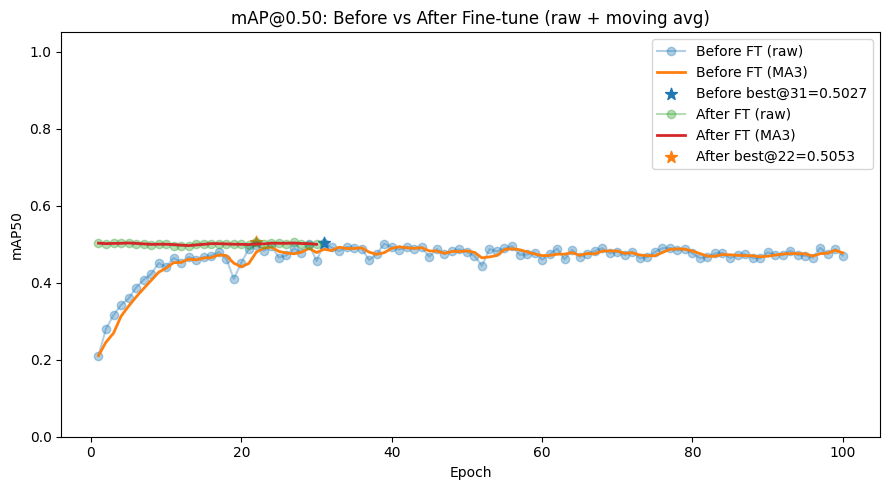

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_map50_before_vs_after_finetune_ma.png


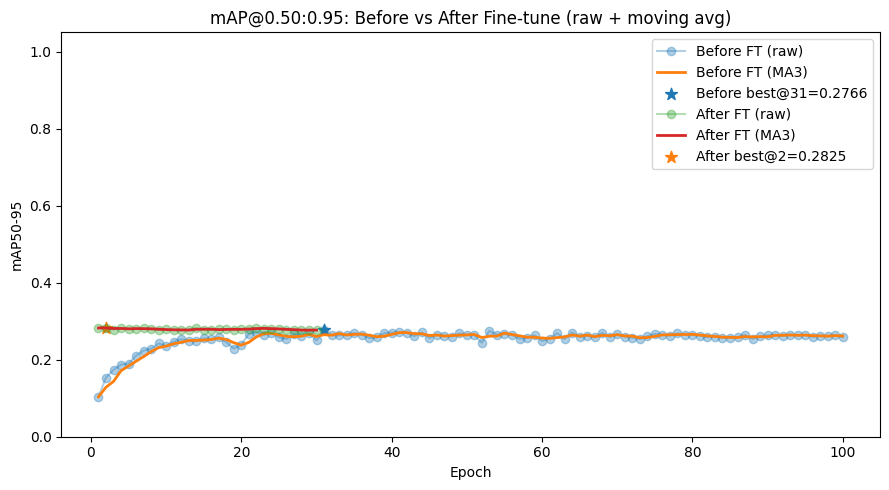

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_map5095_before_vs_after_finetune_ma.png


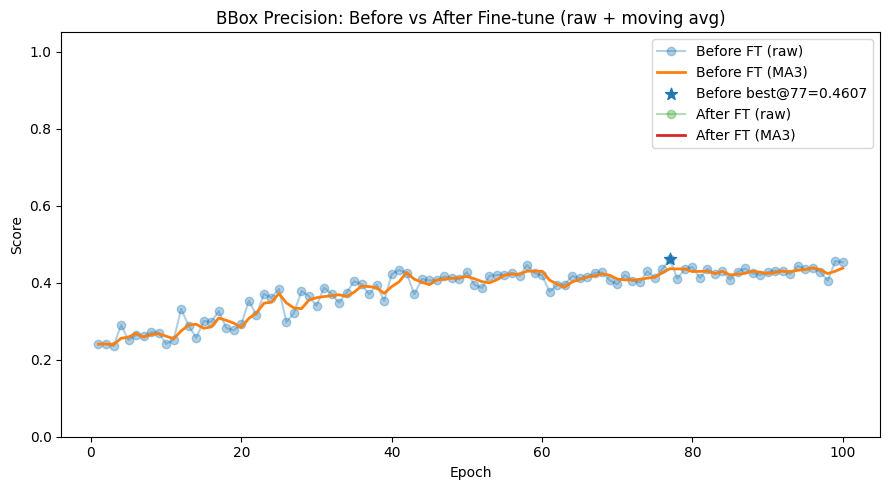

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_bbox_bbox_precision_before_vs_after_finetune_ma.png


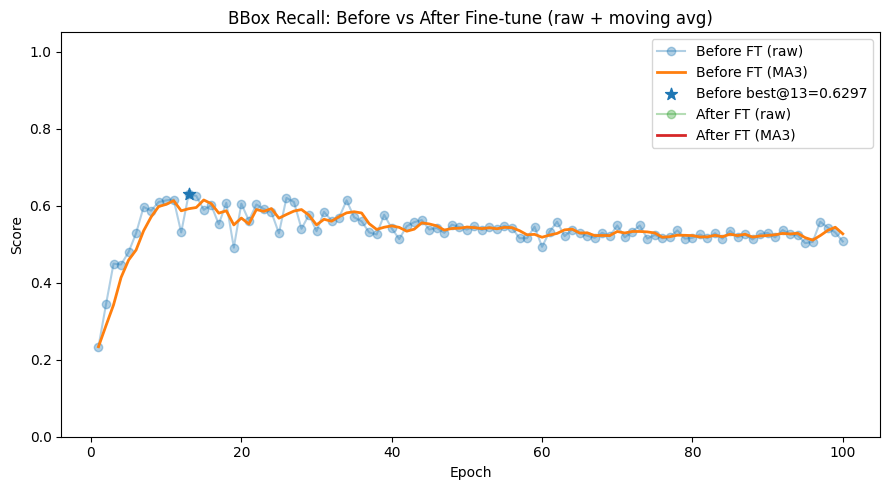

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_bbox_bbox_recall_before_vs_after_finetune_ma.png


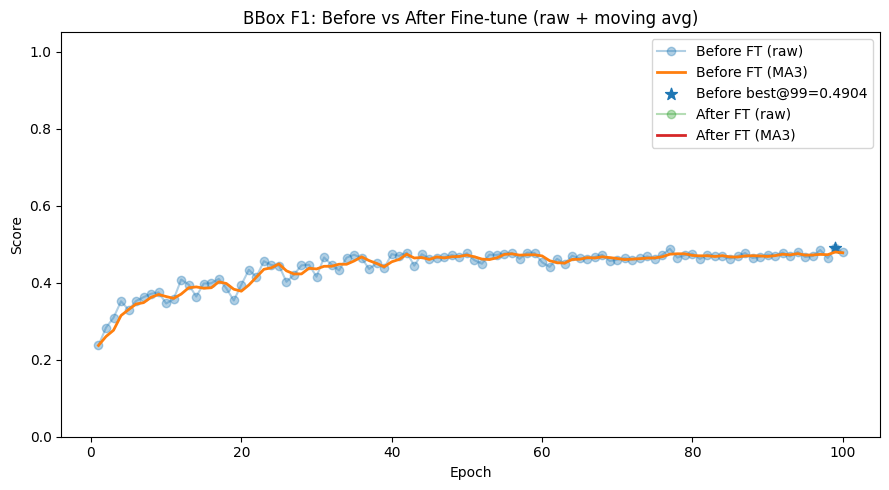

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_bbox_bbox_f1_before_vs_after_finetune_ma.png


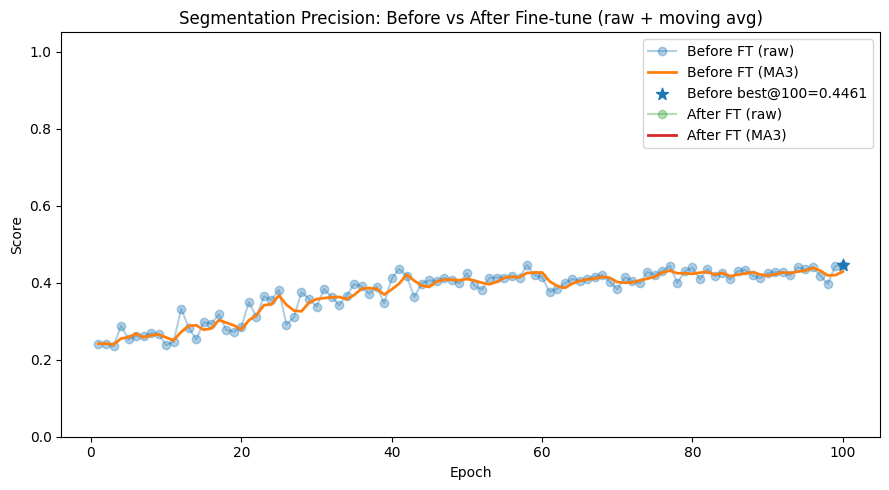

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_segm_segm_precision_before_vs_after_finetune_ma.png


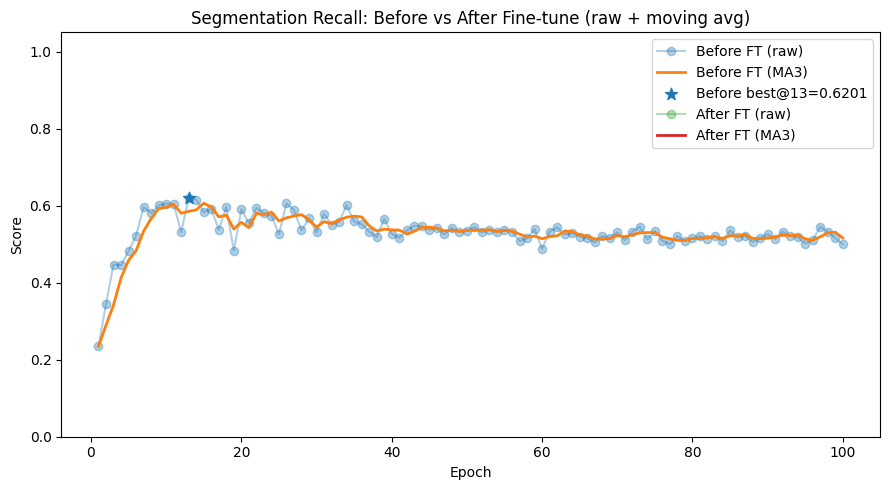

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_segm_segm_recall_before_vs_after_finetune_ma.png


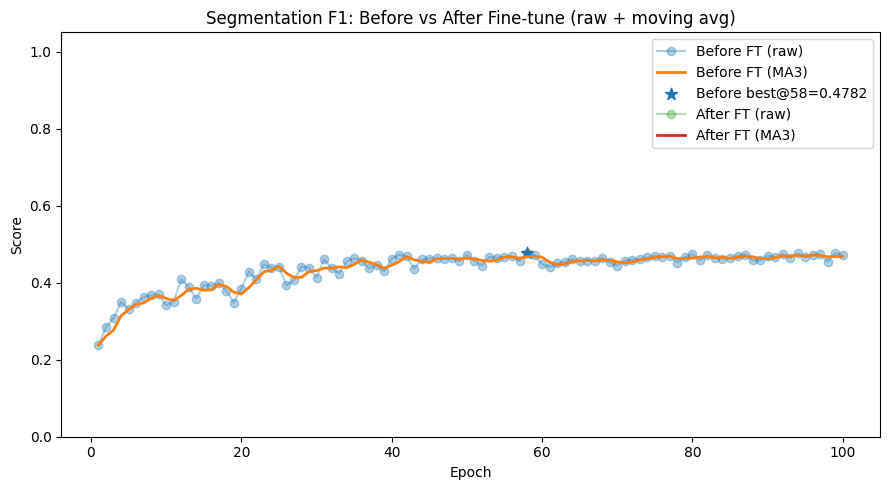

✅ Saved: results_maskrcnn(round_2)\run_baseline_lr0005\plots\compare_segm_segm_f1_before_vs_after_finetune_ma.png

📊 DONE. Compare plots saved to: results_maskrcnn(round_2)\run_baseline_lr0005\plots
ℹ️ Note: split 70/10/20 ทำให้ val แกว่งง่าย -> ดูค่า best/last + moving avg จะตรงกว่า


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PATHS
# =========================
base_log = os.path.join(dirs["run"], "training_log.csv")               # ก่อน fine-tune
ft_log   = os.path.join(dirs["run"], "training_log_finetune.csv")     # หลัง fine-tune

assert os.path.exists(base_log), f"Not found: {base_log}"
assert os.path.exists(ft_log),   f"Not found: {ft_log}"

df_base = pd.read_csv(base_log)
df_ft   = pd.read_csv(ft_log)

# =========================
# to numeric (กัน datatype เพี้ยน)
# =========================
num_cols_base = [
    "epoch","train_loss","mAP50","mAP50_95",
    "bbox_precision","bbox_recall","bbox_f1",
    "segm_precision","segm_recall","segm_f1","time_sec"
]
num_cols_ft = list(set(num_cols_base + ["lr", "phase"]))  # finetune มี lr/phase

for c in num_cols_base:
    if c in df_base.columns:
        df_base[c] = pd.to_numeric(df_base[c], errors="coerce")

for c in num_cols_ft:
    if c in df_ft.columns and c not in ["phase"]:
        df_ft[c] = pd.to_numeric(df_ft[c], errors="coerce")

# =========================
# OUTPUT DIR
# =========================
plots_dir = os.path.join(dirs["run"], "plots")
os.makedirs(plots_dir, exist_ok=True)

# =========================
# helper plot compare
# =========================
def plot_compare(ycol, title, ylabel, fname, ylim=None):
    plt.figure(figsize=(8, 5))

    if ycol in df_base.columns:
        plt.plot(df_base["epoch"], df_base[ycol], marker="o", label=f"Before FT")

    if ycol in df_ft.columns:
        plt.plot(df_ft["epoch"], df_ft[ycol], marker="o", label=f"After FT")

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()

    out = os.path.join(plots_dir, fname)
    plt.savefig(out)
    plt.show()
    print("✅ Saved:", out)

# =========================
# 1) Loss
# =========================
plot_compare(
    ycol="train_loss",
    title="Training Loss: Before vs After Fine-tune",
    ylabel="Loss",
    fname="compare_loss_before_vs_after_finetune.png"
)

# =========================
# 2) mAP (รวมเส้น 4 เส้น)
# =========================
plt.figure(figsize=(8, 5))
plt.plot(df_base["epoch"], df_base["mAP50"], marker="o", label="Before FT mAP@0.50")
plt.plot(df_base["epoch"], df_base["mAP50_95"], marker="o", label="Before FT mAP@0.50:0.95")
plt.plot(df_ft["epoch"], df_ft["mAP50"], marker="o", label="After FT mAP@0.50")
plt.plot(df_ft["epoch"], df_ft["mAP50_95"], marker="o", label="After FT mAP@0.50:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("COCO mAP: Before vs After Fine-tune")
plt.legend()
plt.tight_layout()
out = os.path.join(plots_dir, "compare_map_before_vs_after_finetune.png")
plt.savefig(out)
plt.show()
print("✅ Saved:", out)

# =========================
# 3) BBox PRF1
# =========================
plt.figure(figsize=(8, 5))
for col, name in [("bbox_precision","Precision"), ("bbox_recall","Recall"), ("bbox_f1","F1")]:
    if col in df_base.columns:
        plt.plot(df_base["epoch"], df_base[col], marker="o", label=f"Before FT BBox {name}")
    if col in df_ft.columns:
        plt.plot(df_ft["epoch"], df_ft[col], marker="o", label=f"After FT BBox {name}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("BBox Precision/Recall/F1: Before vs After Fine-tune")
plt.legend()
plt.tight_layout()
out = os.path.join(plots_dir, "compare_bbox_prf1_before_vs_after_finetune.png")
plt.savefig(out)
plt.show()
print("✅ Saved:", out)

# =========================
# 4) Segm PRF1
# =========================
plt.figure(figsize=(8, 5))
for col, name in [("segm_precision","Precision"), ("segm_recall","Recall"), ("segm_f1","F1")]:
    if col in df_base.columns:
        plt.plot(df_base["epoch"], df_base[col], marker="o", label=f"Before FT Segm {name}")
    if col in df_ft.columns:
        plt.plot(df_ft["epoch"], df_ft[col], marker="o", label=f"After FT Segm {name}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Segmentation Precision/Recall/F1: Before vs After Fine-tune")
plt.legend()
plt.tight_layout()
out = os.path.join(plots_dir, "compare_segm_prf1_before_vs_after_finetune.png")
plt.savefig(out)
plt.show()
print("✅ Saved:", out)

print("\n📊 DONE. Compare plots saved to:", plots_dir)

In [23]:
import matplotlib.pyplot as plt
import json

# โหลด log
with open('training_log.json', 'r') as f:
    log = json.load(f)

# สร้างกราฟ
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Training Loss
ax1.plot(log['epoch'], log['train_loss'], label='Train Loss')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# mAP50
ax2.plot(log['epoch'], log['val_mAP50'])
ax2.set_title('Validation mAP50')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP50')

# mAP50-95
ax3.plot(log['epoch'], log['val_mAP50_95'])
ax3.set_title('Validation mAP50-95')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('mAP50-95')

# Training Time per Epoch
ax4.plot(log['epoch'], log['epoch_time'])
ax4.set_title('Training Time per Epoch')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Time (seconds)')

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'training_log.json'

#  Evaluate

In [18]:
import os
from pathlib import Path

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image


# =========================
# CONFIG (แก้ 3 จุดนี้)
# =========================
BEST_PTH = r"C:\skin_train_10_01_69\results_maskrcnn\run_baseline_lr005\checkpoints\best_map5095.pth"     # <-- ใส่ path best.pth ของคุณ
TEST_IMAGES_DIR = r"C:\skin_train_10_01_69\dataset\images\test"       # <-- โฟลเดอร์รูป test (jpg/png)
NUM_CLASSES = 8  # <-- จำนวนคลาสรวม background (เช่น 7 class + background = 8)

BATCH_SIZE = 2
SCORE_THRES = 0.50   # กรองผลทำนายที่ score ต่ำกว่า


# =========================
# Dataset สำหรับ inference (ไม่ต้องมี label)
# =========================
class ImageFolderInference(Dataset):
    def __init__(self, folder: str):
        self.folder = Path(folder)
        exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
        self.paths = sorted([p for p in self.folder.iterdir() if p.suffix.lower() in exts])
        if not self.paths:
            raise FileNotFoundError(f"ไม่พบรูปในโฟลเดอร์: {self.folder}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        img_t = ToTensor()(img)
        return img_t, str(p)

def collate_fn(batch):
    images, paths = zip(*batch)
    return list(images), list(paths)


# =========================
# Build Mask R-CNN (ต้องตรงกับตอนเทรน)
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# weights=None เพื่อไม่โหลด pretrained มาทับโครงหัวท้ายเรา
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

# Replace box head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Replace mask head
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)

# Load weights
state_dict = torch.load(BEST_PTH, map_location=device)
model.load_state_dict(state_dict)

model.to(device)
model.eval()

print("✅ Loaded model:", BEST_PTH)
print("✅ Device:", device)
print("✅ NUM_CLASSES:", NUM_CLASSES)


# =========================
# DataLoader (test images)
# =========================
ds = ImageFolderInference(TEST_IMAGES_DIR)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Found {len(ds)} test images in:", TEST_IMAGES_DIR)


# =========================
# Inference (แสดงผล 1 batch แรก)
# =========================
with torch.inference_mode():
    for images, paths in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i, (path, out) in enumerate(zip(paths, outputs)):
            boxes = out["boxes"].detach().cpu()
            labels = out["labels"].detach().cpu()
            scores = out["scores"].detach().cpu()

            keep = scores >= SCORE_THRES
            boxes_k = boxes[keep].numpy()
            labels_k = labels[keep].numpy()
            scores_k = scores[keep].numpy()

            print("\n" + "=" * 60)
            print("Image:", path)
            print(f"Detections (score >= {SCORE_THRES}): {len(scores_k)}")
            print("Boxes:", boxes_k)
            print("Labels:", labels_k)
            print("Scores:", scores_k)

        break  # เอาแค่ 1 batch แรก (เหมือนที่คุณทำในรูป)

print("\n🎉 Done.")


C:\Users\User\AppData\Local\Temp\ipykernel_40140\1135178436.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(BEST_PTH, map_location=device)


✅ Loaded model: C:\skin_train_10_01_69\results_maskrcnn\run_baseline_lr005\checkpoints\best_map5095.pth
✅ Device: cuda
✅ NUM_CLASSES: 8
✅ Found 140 test images in: C:\skin_train_10_01_69\dataset\images\test

Image: C:\skin_train_10_01_69\dataset\images\test\Acne_0014.jpeg
Detections (score >= 0.5): 29
Boxes: [[335.78256  442.6587   370.67142  475.6053  ]
 [565.0737   131.42355  601.05585  182.15709 ]
 [352.28027  215.93484  449.06564  283.45428 ]
 [149.31122   57.904728 181.41577   93.24996 ]
 [381.8557    80.03815  437.56036  134.92561 ]
 [184.436    385.3823   230.77402  445.2733  ]
 [495.4084   327.0098   565.10156  373.0063  ]
 [412.40933  159.41925  463.00436  204.5602  ]
 [237.69537  150.48854  262.5028   182.6593  ]
 [255.79567   33.039772 324.71707  124.26567 ]
 [662.0054   307.65445  707.0253   343.77847 ]
 [450.59305  256.93655  561.94324  318.85156 ]
 [573.52747  440.8632   665.4043   476.99414 ]
 [582.2409   372.1991   610.28925  405.37265 ]
 [219.50734   72.240486 248.9432

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

In [17]:
# ---------------------------
# 1️⃣ สร้างไฟล์ JSON สำหรับ predictions (COCO format)
# ---------------------------

coco_dt = []  # list ของ dictionary สำหรับ COCO eval

# Keep track of the image index
image_index = 0 
for images, targets in test_loader:
    images = [img.to(device) for img in images]
    predictions = model(images)

    for i, pred in enumerate(predictions):
        # Retrieve the original image info using the global image index
        original_img_info = test_dataset.images[image_index + i]
        image_id = original_img_info["id"]

        boxes  = pred['boxes'].detach().cpu().numpy()
        scores = pred.get('scores', torch.ones(len(boxes))).detach().cpu().numpy()
        labels = pred['labels'].detach().cpu().numpy()


        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box
            width  = x2 - x1
            height = y2 - y1
            coco_dt.append({
                "image_id": int(image_id),
                "category_id": int(label + 1),  # COCO expects 1-indexed
                "bbox": [float(x1), float(y1), float(width), float(height)],
                "score": float(score)
            })
    image_index += len(images) # Increment image index by the batch size




NameError: name 'test_loader' is not defined

In [ ]:
# ---------------------------
# 2️⃣ โหลด COCO GT
# ---------------------------

# ใช้ annotations ของ test set
coco_gt = COCO(os.path.join(data_dir, "test", "_annotations.coco.json"))

# ---------------------------
# 3️⃣ ประเมิน mAP ด้วย COCOeval
# ---------------------------

coco_dt_obj = coco_gt.loadRes(coco_dt)

coco_eval = COCOeval(coco_gt, coco_dt_obj, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()  # แสดง mAP และค่า metric ต่าง ๆ

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.015
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.044
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.113
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

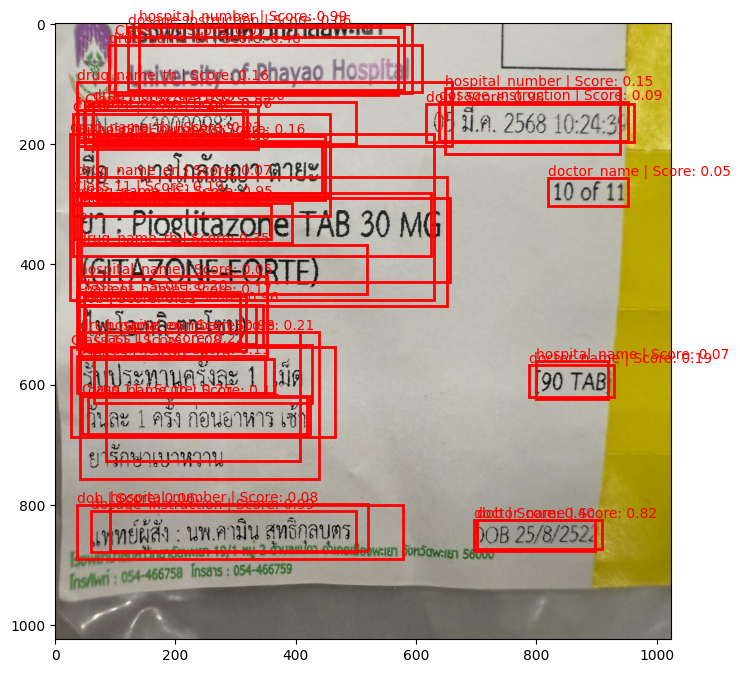

In [ ]:
# ---------------------------
# 4️⃣ วาด bounding boxes บนภาพตัวอย่าง
# ---------------------------

# แสดงภาพแรกใน test set
img_info = test_dataset.images[0]
img_path = os.path.join(img_info["split_dir"], img_info["file_name"])
img = plt.imread(img_path)

# คัดเอา prediction ของภาพนี้
pred = [p for p in coco_dt if p['image_id'] == img_info['id']]

fig, ax = plt.subplots(1, figsize=(12,8))
ax.imshow(img)

for p in pred:
    x, y, w, h = p['bbox']
    rect = patches.Rectangle((x, y), w, h,
                             linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    # Map category_id back to category name for display if categories are available
    category_name = categories.get(p['category_id'] - 1, f"Class {p['category_id']}") # Adjust for 0-indexed categories dict
    ax.text(x, y-5, f"{category_name} | Score: {p['score']:.2f}",
            color='red', fontsize=10)


plt.show()

# use

In [ ]:
import cv2
from PIL import Image
# Load image
img = Image.open("path/to/your/image.jpg")
# Apply the same transformation as for training
img = transform(img)
img = img.unsqueeze(0).to(device)
# Model prediction
model.eval()
with torch.no_grad():
    prediction = model([img])
# Print the predicted bounding boxes and labels
print(prediction[0]['boxes'])
print(prediction[0]['labels'])